# Technical Note P10: SciPy ODE and Time Integration

**Wook Kang · Revised English edition · Version 1.0.0 · 3 October 2026**

This note connects a mathematical task to a numerical object, an implementation, and evidence about the result. It is an instructional computational document. Demonstration parameters are illustrative unless explicitly stated otherwise.

Run from a fresh kernel in cell order. See [the series README](../README.md) for setup and [editorial and verification notes](../docs/EDITORIAL_NOTES.md) for scope and limitations. The English prose has been reorganized and expanded from the supplied Korean notebook; this is an adapted edition rather than a line-by-line translation.

**Reading question:** What is given, what is unknown, what operation relates them, and what independent check can assess the output?

## Core mathematical structure

$$
F(x)=0
$$

$$
\boxed{
\frac{d\mathbf y}{dt}
=
\mathbf f(t,\mathbf y)
}
$$

$$
\mathbf y(t_0)=\mathbf y_0
$$

In [1]:
# Reproducible display and scale-aware comparison.
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False})
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
def scaled_allclose(a, b, rtol=1e-12, atol=None, **kwargs):
    """Compare numerical examples using an absolute tolerance scaled to b."""
    a, b = np.asarray(a), np.asarray(b)
    scale = float(np.max(np.abs(b))) if b.size else 0.0
    if atol is None:
        atol = 1e-14 * max(scale, np.finfo(float).tiny)
    return np.allclose(a, b, rtol=rtol, atol=atol, **kwargs)


## 1. ODEs relate state to rate

The right-hand side supplies dy/dt, not the next state. Its output must match the state shape and have compatible state-per-time units.

$$
\boxed{
\text{state}
\rightarrow
\text{rate}
}
$$

$$
\frac{dy}{dt}=-ky
$$

$$
\dot y=-ky
$$

In [2]:
import numpy as np
from scipy.integrate import solve_ivp

def rhs(t, y, k=0.5):
    return -k*y

print(rhs(0.0, 1.0))

-0.5


## 2. Initial-value problems

A rate law and initial state define an initial-value problem on a time interval. Existence and uniqueness require assumptions beyond a solver call.

$$
\frac{dy}{dt}=-ky,
\qquad
y(0)=1
$$

$$
y(t)=e^{-kt}
$$

In [3]:
k = 0.5

def rhs(t, y):
    return -k*y

sol = solve_ivp(
    rhs,
    t_span=(0.0, 10.0),
    y0=[1.0],
)

print("success =", sol.success)
print("message =", sol.message)
print("number of accepted times =", len(sol.t))
print("final y =", sol.y[0, -1])

success = True
message = The solver successfully reached the end of the integration interval.
number of accepted times = 8
final y = 0.006753920162214615


## 3. The solve_ivp interface

Supply a callable, time interval, and initial vector. Inspect success, status, message, and the final reported time.

```python
solve_ivp(
    fun,
    t_span,
    y0,
    method=...,
    t_eval=...,
    rtol=...,
    atol=...
)
```

## 4. Output times and internal steps

T_eval requests stored output times; it does not prescribe the adaptive internal steps. Use t_eval=None when examining the solver's accepted time grid.

$$
\boxed{
\text{internal integration steps}
\neq
\text{requested output times}
}
$$

In [4]:
t_eval = np.linspace(0, 10, 11)

sol = solve_ivp(
    rhs,
    (0, 10),
    [1.0],
    t_eval=t_eval,
)

print("reported times =", sol.t)
print("reported y =", sol.y[0])

reported times = [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
reported y = [1.         0.60652683 0.36766997 0.22325718 0.13534555 0.08216671
 0.04982546 0.03023536 0.01834578 0.01112766 0.00675392]


## 5. Compare with an exact solution

An analytic exponential provides a simple time-integration benchmark. Evaluate the reference at the same reported times as the numerical output.

In [5]:
y_exact = np.exp(-k*sol.t)
err = np.abs(sol.y[0] - y_exact)

print("max abs error =", np.max(err))

max abs error = 0.00020946819305001085


## 6. Solution-array shape

Sol.y has shape (number of states, number of reported times). A state component is a row and a time snapshot is a column.

```python
sol.y.shape == (n, Nt)
```

In [6]:
print("sol.y shape =", sol.y.shape)

sol.y shape = (1, 11)


## 7. Coupled states

A system may couple several rate laws. Declare the order of state components and derive any conserved totals from those laws.

$$
\frac{dy_1}{dt}=-k_1y_1
$$

$$
\frac{dy_2}{dt}=k_1y_1-k_2y_2
$$

$$
\mathbf y=
\begin{bmatrix}
y_1\\
y_2
\end{bmatrix}
$$

In [7]:
k1, k2 = 1.0, 0.2

def rhs_system(t, y):
    y1, y2 = y
    return [
        -k1*y1,
        k1*y1 - k2*y2,
    ]

sol2 = solve_ivp(
    rhs_system,
    (0, 10),
    [1.0, 0.0],
    t_eval=np.linspace(0,10,101),
)

print("shape =", sol2.y.shape)
print("final state =", sol2.y[:, -1])

shape = (2, 101)
final state = [4.58046460e-05 1.69111879e-01]


## 8. The RHS is a callable

The integrator selects trial times and states, then evaluates the rate function. Hidden mutation or history dependence can invalidate this interface.

$$
(t,\mathbf y)
\mapsto
\frac{d\mathbf y}{dt}
$$

```python
def rhs(t, y):
    ...
```

## 9. Fixed Euler and adaptive integration

Euler uses a specified step and has first-order global accuracy under suitable smoothness. Adaptive methods select steps using local error estimates; the two approaches have different controls.

$$
y^{n+1}=
y^n+\Delta t\,f(t^n,y^n)
$$

In [8]:
def euler(rhs, t0, tf, y0, dt):
    t = t0
    y = float(y0)
    ts = [t]
    ys = [y]

    while t < tf - 1e-15:
        h = min(dt, tf-t)
        y = y + h*rhs(t, y)
        t = t + h
        ts.append(t)
        ys.append(y)

    return np.array(ts), np.array(ys)

te, ye = euler(rhs, 0.0, 10.0, 1.0, 1.0)

print("Euler final =", ye[-1])
print("exact final =", np.exp(-k*10))

Euler final = 0.0009765625
exact final = 0.006737946999085467


## 10. Adaptive stepping

A solver estimates local error, accepts or rejects trial steps, and adjusts the next step. Output density alone does not show how many internal trials were taken.

$$
\text{error small}
\Rightarrow
\Delta t \uparrow
$$

$$
\text{error large}
\Rightarrow
\Delta t \downarrow
$$

## 11. Relative and absolute tolerances

The local error scale combines atol and rtol times state magnitude. These settings do not guarantee the same bound on global physical error; use componentwise atol for differently scaled states.

$$
\text{error}
\lesssim
\text{atol}
+
\text{rtol}\,|y|
$$

In [9]:
for rtol in [1e-3, 1e-6, 1e-9]:
    sol = solve_ivp(
        rhs,
        (0,10),
        [1.0],
        rtol=rtol,
        atol=1e-12,
    )
    err = abs(sol.y[0,-1] - np.exp(-k*10))
    print(f"rtol={rtol:1.0e}, steps={len(sol.t):3d}, final error={err:.3e}")

rtol=1e-03, steps=  8, final error=1.595e-05
rtol=1e-06, steps= 24, final error=8.707e-09
rtol=1e-09, steps= 87, final error=7.468e-12


## 12. Method families

Explicit Runge-Kutta methods suit many nonstiff problems; BDF and Radau are useful for stiffness; LSODA switches families. Choose using observed work, stability, and accuracy needs.

| Method | Type | Use |  
| --- | --- | --- |  
| `RK45` | explicit Runge-Kutta | General nonstiff problems |  
| `RK23` | lower order explicit RK | Lower-order nonstiff integration |  
| `DOP853` | high-order explicit RK | high accuracy nonstiff |  
| `Radau` | implicit RK | stiff |  
| `BDF` | backward differentiation | stiff |  
| `LSODA` | automatic switching | Automatic stiff/nonstiff switching |

## 13. Explicit Runge-Kutta

Intermediate stage evaluations estimate a time update and its error. Method order and stability region are separate properties.

## 14. Stiffness

Fast stable modes can impose small explicit stability steps even when the desired solution evolves slowly. Stiffness is a property of the problem, scale, interval, and method together.

$$
\frac{dy_1}{dt}=-y_1
$$

$$
\frac{dy_2}{dt}=-1000y_2
$$

In [10]:
def stiff_rhs(t, y):
    return [
        -y[0],
        -1000*y[1],
    ]

y0 = [1.0, 1.0]

sol_rk = solve_ivp(
    stiff_rhs,
    (0, 5),
    y0,
    method="RK45",
    rtol=1e-6,
    atol=1e-9,
)

sol_bdf = solve_ivp(
    stiff_rhs,
    (0, 5),
    y0,
    method="BDF",
    rtol=1e-6,
    atol=1e-9,
)

print("RK45 nfev =", sol_rk.nfev, "steps =", len(sol_rk.t))
print("BDF  nfev =", sol_bdf.nfev, "steps =", len(sol_bdf.t))

RK45 nfev = 10796 steps = 1555
BDF  nfev = 406 steps = 203


## 15. Stability restrictions

For linear decay, explicit Euler requires a step within its stability region. A numerically unstable step cannot be repaired merely by plotting more output points.

## 16. BDF

Backward differentiation formulas use implicit multistep relations. Their nonlinear and linear solves add costs but can avoid severe explicit stability restrictions.

$$
\frac{y^{n+1}-y^n}{\Delta t}=
f(t^{n+1},y^{n+1})
$$

$$
\boxed{
\text{implicit time integration}
\rightarrow
\text{nonlinear algebraic solve}
}
$$

## 17. Radau

Radau is an implicit Runge-Kutta family for stiff systems. It still requires tolerances, a well-defined model, and successful internal solves.

## 18. Jacobians for stiff solvers

Provide a consistent Jacobian or sparsity pattern when useful. For a linear semidiscrete system, the constant matrix is the exact state Jacobian.

$$
J=\frac{\partial f}{\partial y}
$$

In [11]:
def stiff_jac(t, y):
    return np.array([
        [-1.0, 0.0],
        [0.0, -1000.0],
    ])

sol_bdf_j = solve_ivp(
    stiff_rhs,
    (0,5),
    y0,
    method="BDF",
    jac=stiff_jac,
    rtol=1e-6,
    atol=1e-9,
)

print("success =", sol_bdf_j.success)
print("nfev =", sol_bdf_j.nfev)
print("njev =", sol_bdf_j.njev)

success = True
nfev = 406
njev = 1


## 19. Dense output

Dense output supplies a numerical interpolant within integrated intervals. It is not an exact solution and should not be extrapolated casually.

In [12]:
sol_dense = solve_ivp(
    rhs,
    (0,10),
    [1.0],
    dense_output=True,
)

tq = np.array([0.3, 1.7, 4.2])
yq = sol_dense.sol(tq)

print("query times =", tq)
print("interpolated y =", yq)

query times = [0.3 1.7 4.2]
interpolated y = [[0.86069547 0.42728013 0.1224861 ]]


## 20. Events

Events locate zeros of a scalar function of time and state. Multiple crossings within one step can be missed, so resolution and max_step may matter.

$$
y(t)=0.2
$$

In [13]:
def event_y02(t, y):
    return y[0] - 0.2

event_y02.terminal = True
event_y02.direction = -1

sol_event = solve_ivp(
    rhs,
    (0,20),
    [1.0],
    events=event_y02,
    rtol=1e-9,
    atol=1e-12,
)

print("event time =", sol_event.t_events[0])
print("event state =", sol_event.y_events[0])

event time = [3.21887583]
event state = [[0.2]]


## 21. Crossing direction

Direction selects increasing, decreasing, or either crossing. Terminal controls whether an event stops integration.

## 22. Pass parameters

Args supplies additional parameters to the RHS and relevant callbacks. Keep the signatures consistent for event and Jacobian functions.

In [14]:
def rhs_param(t, y, k):
    return -k*y

sol_param = solve_ivp(
    rhs_param,
    (0,5),
    [1.0],
    args=(0.8,),
)

print(sol_param.y[0,-1])

0.01834875160663251


## 23. Time-dependent forcing

A source can depend explicitly on time. Known discontinuities are best handled with deliberate interval splitting and state continuity rather than hoping error control detects them.

$$
\frac{dy}{dt}=
-ky+s(t)
$$

In [15]:
def forced_rhs(t, y):
    source = np.sin(t)
    return -0.5*y + source

sol_forced = solve_ivp(
    forced_rhs,
    (0,20),
    [0.0],
    t_eval=np.linspace(0,20,401),
)

print("success =", sol_forced.success)

success = True


## 24. Plot a time history

Label the state and time units. Inspect transients, signs, event locations, and comparisons rather than only the final value.

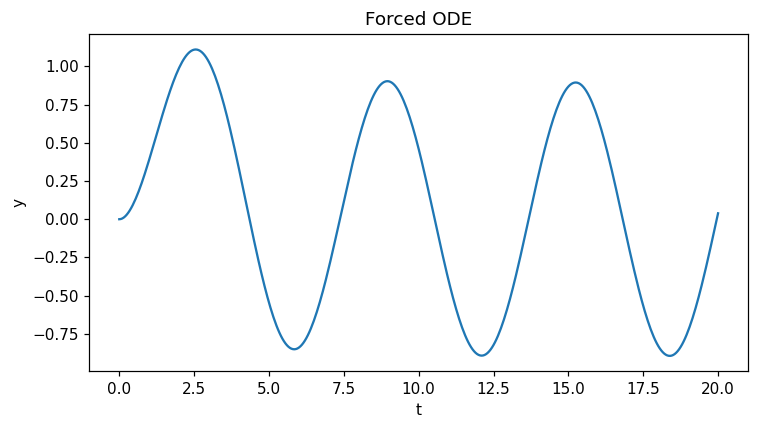

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(sol_forced.t, sol_forced.y[0])
plt.xlabel("t")
plt.ylabel("y")
plt.title("Forced ODE")
plt.tight_layout()
plt.show()

## 25. Coupled heat exchange

The two-body model exchanges equal and opposite heat rates. Heat capacities determine the temperature-rate response and the conserved weighted energy.

$$
C_1\frac{dT_1}{dt}=
-h(T_1-T_2)
$$

$$
C_2\frac{dT_2}{dt}=
+h(T_1-T_2)
$$

In [17]:
C1, C2 = 1.0, 2.0
h = 0.5

def thermal_pair(t, T):
    T1, T2 = T
    q = h*(T1-T2)
    return [
        -q/C1,
         q/C2,
    ]

sol_T = solve_ivp(
    thermal_pair,
    (0,20),
    [100.0, 20.0],
    t_eval=np.linspace(0,20,201),
)

print("final temperatures =", sol_T.y[:,-1])

final temperatures = [46.67333017 46.66333492]


## 26. Conservation

Check the invariant implied by the rate equations. Conservation agreement is a strong internal check but does not establish that the chosen physical model is adequate.

$$
E=C_1T_1+C_2T_2
$$

In [18]:
E = C1*sol_T.y[0] + C2*sol_T.y[1]

print("energy variation =", E.max() - E.min())

energy variation = 0.0


## 27. Semidiscrete PDEs

Spatial discretization turns a PDE into a vector ODE. The operator, boundaries, and unknown ordering define this ODE before time integration begins.

$$
\frac{\partial u}{\partial t}=
D\frac{\partial^2u}{\partial x^2}
$$

$$
\frac{d\mathbf U}{dt}=
A\mathbf U
$$

$$
\boxed{
\text{PDE}
\rightarrow
\text{space discretization}
\rightarrow
\text{large ODE system}
}
$$

## 28. One-dimensional diffusion

The example uses interior unknowns and homogeneous Dirichlet boundaries. BDF integrates the diffusion matrix, and the revised example supplies that matrix as its Jacobian.

$$
u(0,t)=u(1,t)=0
$$

In [19]:
from scipy import sparse

D = 0.1
N = 40
L = 1.0
dx = L/(N+1)

A = D * sparse.diags(
    [np.ones(N-1), -2*np.ones(N), np.ones(N-1)],
    [-1, 0, 1],
    format="csr",
) / dx**2

x = np.linspace(dx, L-dx, N)
u0 = np.sin(np.pi*x)

def diffusion_rhs(t, u):
    return A @ u

sol_diff = solve_ivp(
    diffusion_rhs,
    (0,1),
    u0,
    method="BDF",
    jac=A,
    t_eval=np.linspace(0,1,6),
    rtol=1e-7,
    atol=1e-9,
)

print("state dimension =", len(u0))
print("sol shape =", sol_diff.y.shape)
print("success =", sol_diff.success)

state dimension = 40
sol shape = (40, 6)
success = True


## 29. An exact discrete mode

For a centred stencil, the sampled sine has a discrete eigenvalue different from the continuum eigenvalue. Comparing against its matrix-exponential mode isolates time-integration error.

$$
u(x,0)=\sin(\pi x)
$$

$$
u(x,t)=
e^{-D\pi^2t}\sin(\pi x)
$$

In [20]:
t_final = sol_diff.t[-1]
u_num = sol_diff.y[:,-1]
u_exact = np.exp(-D*np.pi**2*t_final)*np.sin(np.pi*x)

print("max error =", np.max(np.abs(u_num-u_exact)))

max error = 0.00017985826995520204


## 30. Separate time and space errors

Compare the numerical state with the exact discrete mode, then the discrete mode with the continuum solution. Tightening time tolerances cannot remove fixed-grid spatial error.

$$
\boxed{
\text{spatial discretization error}
+
\text{time integration error}
+
\text{nonlinear/linear solver error}
}
$$

$$
\boxed{
\text{ODE tolerance}
\neq
\text{PDE total accuracy}
}
$$

## 31. The semidiscrete Jacobian

For du/dt=A-u, the Jacobian is A. For nonlinear coefficients, derivatives of the coefficient and boundary law also contribute.

$$
\dot U=AU
$$

$$
J=A
$$

$$
\dot U=F(U)
$$

$$
J=\frac{\partial F}{\partial U}
$$

## 32. Maximum internal step

Max_step limits accepted step size but does not create fixed-step integration. Use it when resolving known forcing or event scales.

```python
max_step=...
```

In [21]:
sol_limit = solve_ivp(
    rhs,
    (0,10),
    [1.0],
    max_step=0.2,
)

print("number of steps =", len(sol_limit.t))

number of steps = 52


## 33. Solver statistics

Nfev, njev, and nlu describe computational work. Fewer calls alone do not establish equal accuracy or physical validity.

In [22]:
sol_stats = solve_ivp(
    stiff_rhs,
    (0,5),
    [1.0,1.0],
    method="BDF",
)

print("success =", sol_stats.success)
print("nfev =", sol_stats.nfev)
print("njev =", sol_stats.njev)
print("nlu =", sol_stats.nlu)

success = True
nfev = 166
njev = 1
nlu = 19


## 34. Do not assume stiffness from a label

Inspect time scales, eigenvalues where informative, and solver work. A diffusion discretization becomes more demanding as the mesh is refined.

$$
\boxed{
\text{widely separated time scales}
+
\text{explicit stability restriction}
}
$$

## 35. Choose a time solver

Begin with the model's scales, regularity, and Jacobian structure. Compare methods at a specified accuracy rather than their defaults alone.

| Situation | Initial candidate |  
| --- | --- |  
| General nonstiff problems | `RK45` |  
| High-accuracy nonstiff problems | `DOP853` |  
| stiff | `BDF` |  
| Stiff problems with an implicit RK preference | `Radau` |  
| Uncertain stiffness | Consider `LSODA` |  
| Event detection required | Events supported by the principal methods |

## 36. When fixed steps remain useful

Fixed steps simplify coupling, reproducible schedules, and some algorithmic comparisons. They still need stability and convergence assessment.

$$
\boxed{
\text{adaptive}
\neq
\text{always better}
}
$$

## 37. Time refinement

For a fixed-step method, compare several decreasing steps. For an adaptive method, vary tolerances while controlling spatial and model errors separately.

$$
\Delta t,\quad
\frac{\Delta t}{2},\quad
\frac{\Delta t}{4}
$$

$$
\boxed{
\text{solver finished}
\neq
\text{time discretization verified}
}
$$

## 38. Time-integration map

Distinguish the rate callable, initial state, method, internal steps, output grid, events, and error assessment. They are different parts of one calculation.

| Problem | SciPy |  
| --- | --- |  
| IVP $\dot y=f(t,y)$ | `solve_ivp` |  
| nonstiff | `RK45`, `DOP853` |  
| stiff | `BDF`, `Radau` |  
| automatic stiff/nonstiff | `LSODA` |  
| output times | `t_eval` |  
| dense interpolation | `dense_output=True` |  
| event | `events=` |  
| Jacobian | `jac=` |  
| max internal step | `max_step` |  
| error control | `rtol`, `atol` |

## 39. Continue to P11

Parameter estimation repeatedly invokes a forward calculation. Its stopping criteria and data limitations require a further layer of assessment.

$$
\boxed{
\dot y=f(t,y)
\rightarrow
\min_\theta \Phi(\theta)
}
$$

## Supplement: independent numerical checks

These checks target mathematical invariants or an independent reference. They do not validate a wood constitutive law against observations. Tolerances belong to the stated example and tested environment.

In [23]:
# The discrete sine mode isolates time error from spatial approximation error.
lambda_discrete = -4*D*np.sin(np.pi/(2*(N+1)))**2/dx**2
reference_discrete = np.exp(lambda_discrete*sol_diff.t[-1])*u0
reference_continuum = np.exp(-D*(np.pi/L)**2*sol_diff.t[-1])*u0
assert sol_diff.success
assert abs(sol_diff.t[-1]-1.0)<1e-14
np.testing.assert_allclose(A@u0,lambda_discrete*u0,rtol=1e-11,atol=1e-11)
time_error=np.max(np.abs(sol_diff.y[:,-1]-reference_discrete))
space_error=np.max(np.abs(reference_discrete-reference_continuum))
assert time_error<2e-6
assert np.max(np.abs(E-E[0]))<1e-10
assert sol_event.success and sol_event.status==1
np.testing.assert_allclose(sol_event.t_events[0],[np.log(5)/k],rtol=1e-7,atol=1e-9)
print("Time integration error against the discrete mode:",time_error)
print("Spatial-mode error against the continuum:",space_error)
print("Thermal conservation and event-time checks passed.")


Time integration error against the discrete mode: 4.272254494619432e-09
Spatial-mode error against the continuum: 0.00017985399770070742
Thermal conservation and event-time checks passed.


## Further work

1. Change one parameter or discretization choice and predict the effect before running.
2. Write the input and output shapes, units, and field locations.
3. Construct a deliberately invalid input and make the calculation report it clearly.
4. Separate an execution check from an accuracy check and from any physical claim.

## Primary documentation

- [SciPy solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)

These are living documentation links. The accompanying requirements and verification report identify the versions actually executed for this edition.

## AI assistance and responsibility

The English adaptation, editorial supplementation, and code review were prepared with AI assistance. Wook Kang retains responsibility for reviewing the explanations, examples, and any subsequent research application. No new experimental validation is claimed.